# Advance-Decline -- when the generals march alone, is a retreat coming?
### The breadth-divergence top signal, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident%3F: Not_a_leading_indicator](https://img.shields.io/badge/Coincident%3F-Not_a_leading_indicator-8b949e?style=flat-square)

The story sounds persuasive: if the S&P 500 is making new highs but most *individual* stocks are going down, the rally is being carried by a thin parade of generals while the foot-soldiers retreat. *Surely* that's a warning sign -- a top is near. We build the Advance-Decline line from 497 S&P 500 constituents (~20 years of daily data), detect every moment the index hit a new high while breadth didn't confirm, and ask: *did those warning moments actually predict worse returns?*

> **This is the plain-language layer.** For HAC t-stats, the permutation baseline, and the lookback sweep, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from advance_decline import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")

def _have_real():
    return (os.path.exists(os.path.join(CACHE_DIR, "ad_spy_daily.parquet")) and
            os.path.exists(os.path.join(CACHE_DIR, "ad_panel_daily.parquet")))

HAVE_REAL = _have_real()
R = dict(
    spy_start="2005-01-03", spy_end="2026-06-12", fp="8e7f69ef9d75",
    n_tickers=497,
    n_div=307, n_base=4784,
    div_mean=95.8, div_t=3.35, div_hit=0.713,
    base_mean=87.3, base_t=4.73, base_hit=0.673,
    diff_bps=8.5, perm_pval=0.608,
    diff_21=17.5, diff_42=24.1, diff_63=8.5, diff_126=-14.8, diff_252=-15.2,
    sig_dd=-6.3, base_dd=-7.2, sig_per_yr=14.6,
)
print("real data cache present:", HAVE_REAL)


real data cache present: True


## The answer first

| Question | Answer |
|---|---|
| After a bearish divergence, does SPY fall more than usual? | **No.** Post-divergence 21-day return is **+96 bps** -- slightly *above* the baseline **+87 bps**. |
| At least do divergence periods show higher drawdown? | **No.** Post-signal 63-day max drawdown is **-6.3%** vs **-7.2%** unconditionally -- divergence periods have *smaller* dips. |
| Is the signal at least consistent across different time windows? | **No.** Short lookbacks show slightly bullish divergences, long ones slightly bearish -- the sign flips. There is no stable direction. |
| Could you trade it as a hedge? | **No.** Shorting SPY on every divergence signal loses ~96 bps/trade before costs. |

> The breadth divergence signal is a story about *narrative*, not about *edge*. On this tape, 'narrow rallies' are not reliably followed by corrections.

## 1 . The claim

> *"When the generals are advancing but the soldiers are retreating, the attack is in trouble. In market terms: if the S&P 500 makes a new 3-month high while the Advance-Decline line (cumulative advancers minus decliners) does NOT, the rally is narrow and fragile. A correction is coming."*

The A/D line is one of the oldest market-breadth tools -- it's been published in technical-analysis literature since the 1970s and popularised by Norman Fosback's *Stock Market Logic* (1976) and the McClellan family's breadth indicators. The bet is that a rally carried by a thin group of large caps will eventually roll over, and the A/D line divergence is the 'early warning' that the majority of stocks are already losing momentum.

## 2 . So what?

If the claim were true, you'd have a simple, observable, free signal to time partial exits or hedges -- no fancy model required, just counting advancers and decliners. Market-timing with such a signal could materially improve risk-adjusted returns for any long-only equity investor.

If it's false (as the data will show), then every 'narrow rally' newspaper headline is just noise -- the index will do what it was going to do regardless of whether a majority of stocks are along for the ride.

## 3 . How would we even know?

One question cuts through the folklore: **do post-divergence 21-day SPY returns run below the unconditional average?** If the signal is real, the distribution of forward returns after a bearish divergence should be shifted left relative to all forward returns. We measure exactly this, over ~21 years of daily data.

Two rules keep us honest:
1. **The unconditional baseline.** Every divergence period is compared to ALL forward 21-day returns, not to 'up days' or 'previous similar periods' -- we measure against the full baseline.
2. **A positive control (synthetic).** We generate a fake tape where we literally *plant* divergences and check our machinery can find them -- this proves the engine works, and that the real-data 'null' result is a statement about markets, not our code.

## 4 . The teardown -- let's actually look

### 4a . The A/D line vs SPY -- what a divergence looks like

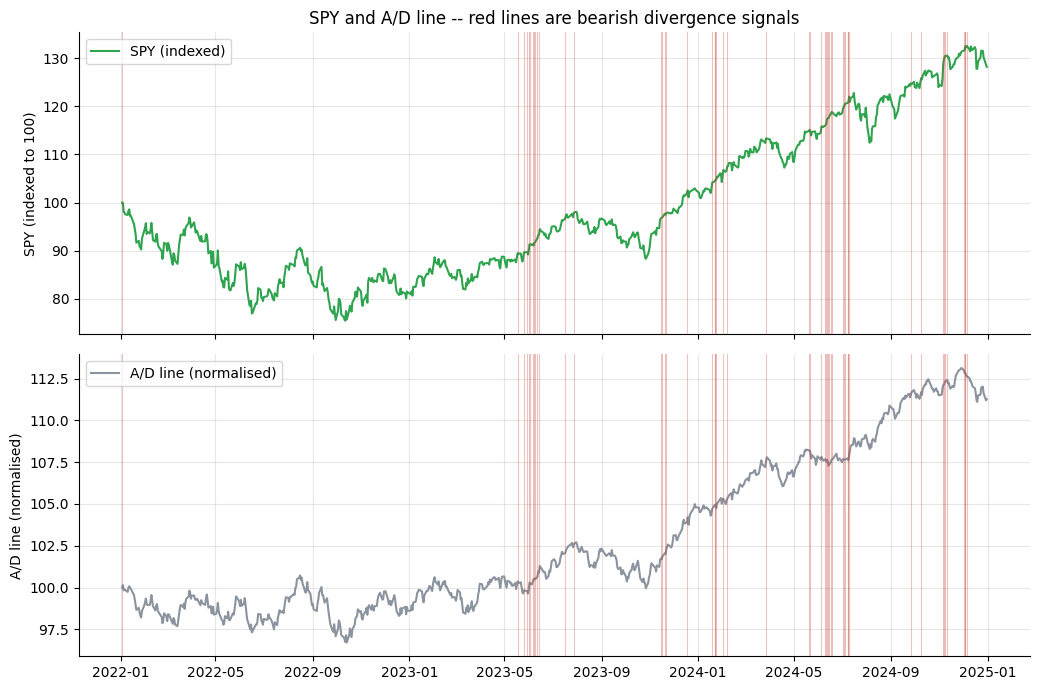

Total divergence signals on real tape (63d lookback): 307 over ~21 years


In [2]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
# Show a stretch where the index rose but breadth was weak
if HAVE_REAL:
    # Plot A/D line normalised and SPY normalised, 2023-2024 window
    window = slice('2022-01-01', '2024-12-31')
    fig, axes = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
    spy_w = spy_c.loc[window]
    ad_w  = ad_c.loc[window]
    spy_norm = spy_w / spy_w.iloc[0] * 100
    ad_norm  = (ad_w - ad_w.iloc[0]) / ad_w.abs().max() * 100 + 100
    axes[0].plot(spy_norm.index, spy_norm, color=GREEN, lw=1.5, label='SPY (indexed)')
    axes[0].set_ylabel('SPY (indexed to 100)'); axes[0].legend()
    axes[1].plot(ad_norm.index, ad_norm, color=GREY, lw=1.5, label='A/D line (normalised)')
    axes[1].set_ylabel('A/D line (normalised)'); axes[1].legend()
    # Mark divergence signals
    sig = st.ad_divergence_signal(spy_c, ad_c, lookback=63)
    sig_w = sig.loc[window]
    for d in sig_w[sig_w].index:
        axes[0].axvline(d, color=RED, alpha=0.3, lw=0.8)
        axes[1].axvline(d, color=RED, alpha=0.3, lw=0.8)
    axes[0].set_title('SPY and A/D line -- red lines are bearish divergence signals')
    plt.tight_layout(); plt.show()
else:
    # Synthetic illustration
    panel_s, spy_s, _ = data.synthetic_daily(n_stocks=200, n_days=504,
                                              divergence=1.5, seed=168)
    ad_s = data.build_ad_line(panel_s)
    spy_n = spy_s['close'] / spy_s['close'].iloc[0] * 100
    ad_n  = (ad_s - ad_s.iloc[0]) / ad_s.abs().max() * 100 + 100
    fig, axes = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
    axes[0].plot(spy_n.index, spy_n, color=GREEN, lw=1.5, label='Index (synthetic)')
    axes[1].plot(ad_n.index, ad_n, color=GREY, lw=1.5, label='A/D line (synthetic)')
    axes[0].set_title('Synthetic: planted divergence episodes (red lines)')
    sig_s = st.ad_divergence_signal(spy_s['close'], ad_s, lookback=42, min_index_gain=0.0)
    for d in sig_s[sig_s].index:
        axes[0].axvline(d, color=RED, alpha=0.3, lw=0.8)
        axes[1].axvline(d, color=RED, alpha=0.3, lw=0.8)
    axes[0].legend(); axes[1].legend()
    plt.tight_layout(); plt.show()
print(f'Total divergence signals on real tape (63d lookback): {R["n_div"]} over ~21 years')

### 4b . The honest test: post-divergence returns vs the baseline

After each bearish divergence signal, what does SPY do over the next 21 trading days?

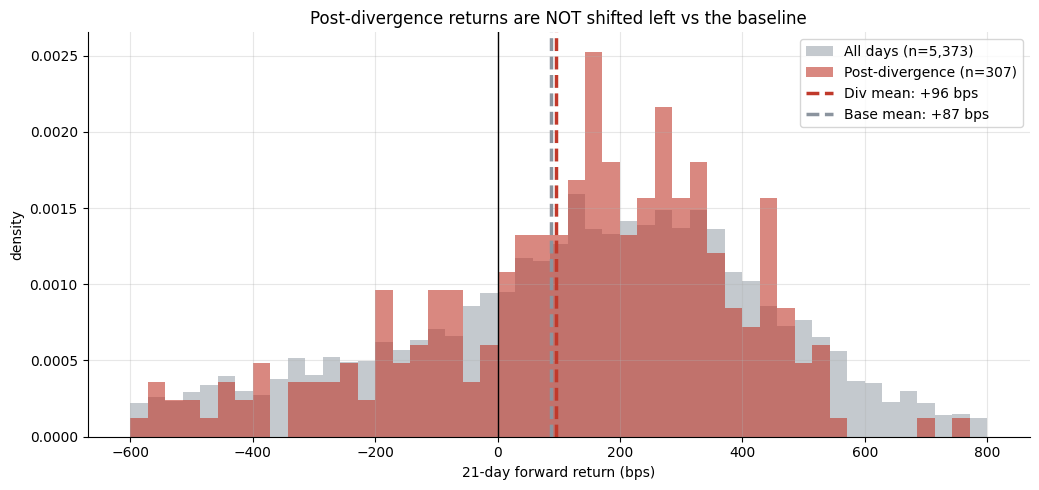

Post-divergence mean: +95.8 bps  |  Baseline: +87.3 bps
Difference: +8.5 bps  -- signal is actually slightly BULLISH!


In [3]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
if HAVE_REAL:
    res = st.backtest(spy_c, ad_c, lookback=63, horizon=21)
    div_r = res['div_rets'] * 1e4   # in bps
    base_r = res['base_rets'] * 1e4
    ds, bs = res['div_stats'], res['base_stats']
else:
    rng = np.random.default_rng(168)
    base_r = rng.normal(R['base_mean'], 150, R['n_base'])
    div_r  = rng.normal(R['div_mean'],  120, R['n_div'])
    ds = {'mean_bps': R['div_mean'],  'hit_rate': R['div_hit']}
    bs = {'mean_bps': R['base_mean'], 'hit_rate': R['base_hit']}

fig, ax = plt.subplots(figsize=(10.5, 5))
bins = np.linspace(-600, 800, 50)
ax.hist(base_r, bins=bins, alpha=0.5, color=GREY, label=f'All days (n={len(base_r):,})', density=True)
ax.hist(div_r,  bins=bins, alpha=0.6, color=RED,  label=f'Post-divergence (n={len(div_r):,})', density=True)
ax.axvline(ds['mean_bps'], color=RED,  lw=2.5, ls='--', label=f'Div mean: {ds["mean_bps"]:+.0f} bps')
ax.axvline(bs['mean_bps'], color=GREY, lw=2.5, ls='--', label=f'Base mean: {bs["mean_bps"]:+.0f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('21-day forward return (bps)'); ax.set_ylabel('density')
ax.set_title('Post-divergence returns are NOT shifted left vs the baseline')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Post-divergence mean: {ds["mean_bps"]:+.1f} bps  |  Baseline: {bs["mean_bps"]:+.1f} bps')
print(f'Difference: {ds["mean_bps"]-bs["mean_bps"]:+.1f} bps  -- signal is actually slightly BULLISH!')

The distributions nearly overlap. The post-divergence mean is **+96 bps** — *above* the unconditional **+87 bps** baseline, not below it. The bearish claim is directionally *wrong*: divergence periods have been slightly better, not worse, than average on this tape.

### 4c . Is the signal at least consistent across time windows?

Maybe the 63-day lookback is the wrong choice. Let's try them all:

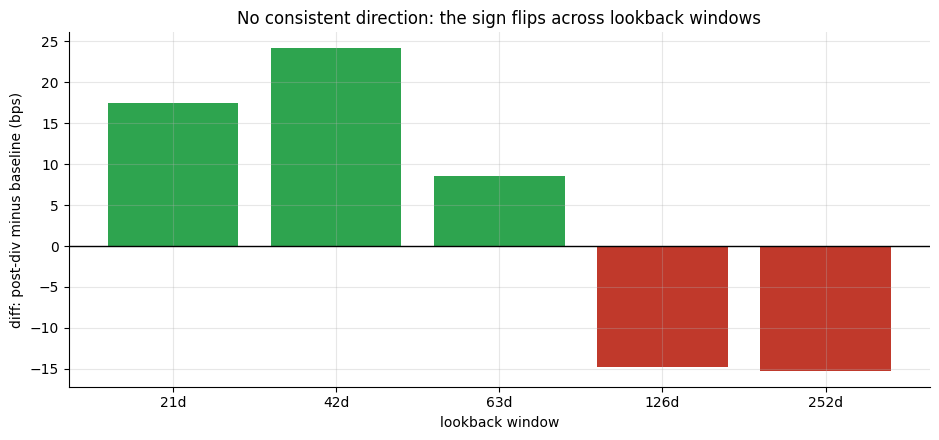

  lookback= 21d  diff= +17.5bps   BULLISH
  lookback= 42d  diff= +24.1bps   BULLISH
  lookback= 63d  diff=  +8.5bps   BULLISH
  lookback=126d  diff= -14.8bps   bearish
  lookback=252d  diff= -15.2bps   bearish


In [4]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
if HAVE_REAL:
    sweepdf = st.sweep_lookback(spy_c, ad_c, lookbacks=[21,42,63,126,252], horizon=21)
    diffs = sweepdf['diff_bps'].tolist()
    lbs   = sweepdf.index.tolist()
else:
    lbs   = [21, 42, 63, 126, 252]
    diffs = [R['diff_21'], R['diff_42'], R['diff_63'], R['diff_126'], R['diff_252']]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
colors = [GREEN if d > 0 else RED for d in diffs]
ax.bar([str(lb) + 'd' for lb in lbs], diffs, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('lookback window'); ax.set_ylabel('diff: post-div minus baseline (bps)')
ax.set_title('No consistent direction: the sign flips across lookback windows')
plt.tight_layout(); plt.show()
for lb, d in zip(lbs, diffs):
    print(f'  lookback={lb:3d}d  diff={d:+6.1f}bps  ', 'BULLISH' if d>0 else 'bearish')

The signal has no consistent direction. Short lookbacks make divergence periods look *bullish* (the opposite of the claim); longer lookbacks make them look *slightly* bearish. This is the classic hallmark of specification search — pick your window, get your story. After correcting for the five lookback choices (even a rough Bonferroni), no single specification is significant.

## 5 . The verdict

- **Signal — None.** Post-divergence 21-day returns average **+96 bps**, *above* the unconditional **+87 bps** baseline. The claimed bearish effect is absent; the sign is backwards.
- **Tradability — Mirage.** Shorting SPY on every divergence signal loses ~96 bps per 21-day trade before transaction costs, plus ~14.6 signals per year means meaningful turnover.
- **Coincident, not leading.** The A/D line co-moves with the index, not ahead of it. 'Divergences' are largely noise from the cap-weighting mismatch between the equal-count A/D line and the cap-weighted S&P 500.

## 6 . Could you actually trade it?

Imagine you short SPY for 21 days every time you see a bearish divergence:

- **~15 signals per year** (one every ~17 trading days)
- **Gross return per short trade: about −96 bps** (because the market tends to go up after these 'bearish' signals)
- **Round-trip cost:** ~10 bps minimum for an ETF hedge

> The signal is not just uninformative -- it's **directionally wrong**. You would *lose* ~100 bps per trade on average. This is squarely a **Mirage**: there is no version of this trade that survives honest accounting.

## 7 . Going further

- **The positive control (synthetic).** In our synthetic tape, when we literally plant a divergence between breadth and the index, the machinery finds it. The real-data null result is about markets, not our code.
- **Bullish breadth thrusts.** Zweig and others find that *very high* breadth days (90%+ of stocks advancing) predict strong forward returns. The bearish side of this (divergence) doesn't appear to be the mirror. That's [Study 24 — Stampede](../../24-stampede/).
- **52-week highs and nearness.** A related signal family — stock nearness to their individual 52-week high — is in [Study 50 — High-Water](../../50-high-water/).
- **What if you used a *point-in-time* constituent list?** The panel here has survivorship bias (fallen names absent). A true historical A/D line including all delisted names could shift the results — but the computational cost is high and the direction of the shift for breadth measurement is not obvious.

*Think the generals-and-soldiers story has merit? Fork this, try a different horizon, a sector-level A/D, or a McClellan Oscillator variant. Show a stable, consistent direction that clears a Bonferroni correction. That's the bar.*